# 1.3 — Health Gain Exploration & Bias Analysis

## What is this notebook about?

This notebook explores **health gain** for NHS Knee Replacement patients.

| Term | Definition |
|------|-----------|
| **OKS Pre Score** | Oxford Knee Score before surgery (0 = worst, 48 = best) |
| **OKS Post Score** | Oxford Knee Score after surgery |
| **Health Gain** | Post Score − Pre Score |
| **Benefit** (0) | Health Gain > 7 — the patient improved meaningfully |
| **No Benefit** (1) | Health Gain ≤ 7 — minimal or no improvement |

A threshold of **7 points** is used because the minimum clinically important difference (MCID) for OKS is widely accepted as around 7.

**Key questions:**
1. How is the data split between Benefit and No Benefit? (class bias)
2. What does the health gain distribution look like?
3. Does age band or gender influence outcomes?
4. Which pre-op features correlate with health gain?

In [38]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Consistent visual style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.axisbelow":    True,   # gridlines rendered behind bars/lines
    "grid.color":        "#e0e0e0",
    "grid.linewidth":    0.6,
    "font.size":         11,
})

# ── Color palette — change hex values here to update all charts at once ──────
BENEFIT    = "#3A7D44"   # label 0 — green  = good outcome
NO_BENEFIT = "#C0392B"   # label 1 — red    = flag / poor outcome
THRESH     = "#E67E22"   # threshold line   — amber, distinct from both

pd.set_option("display.float_format", "{:.2f}".format)
print("Libraries loaded.")

Libraries loaded.


## Load Data

In [39]:
from pathlib import Path

DATA_PATH = Path("./data/interim/1.1-Reduced.parquet")
df = pl.read_parquet(DATA_PATH)

PRE_COL  = "Knee Replacement Pre-Op Q Score"
POST_COL = "Knee Replacement Post-Op Q Score"

print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nPre-Op Score  — nulls: {df[PRE_COL].null_count():,}  range: [{df[PRE_COL].min()}, {df[PRE_COL].max()}]")
print(f"Post-Op Score — nulls: {df[POST_COL].null_count():,}  range: [{df[POST_COL].min()}, {df[POST_COL].max()}]")

Rows   : 139,236
Columns: 82

Pre-Op Score  — nulls: 1,669  range: [0.0, 48.0]
Post-Op Score — nulls: 2,579  range: [0.0, 48.0]


---
## Section 1 — Compute Health Gain & Patient Categorisation

**Health Gain** = OKS Post Score − OKS Pre Score

- Positive value → the patient improved after surgery
- Negative value → the patient's score got worse

**Classification threshold = 7 points** (minimum clinically important difference)

| Label | Meaning | Condition |
|-------|---------|-----------|
| **0 — Benefit** | Meaningful improvement | Health Gain > 7 |
| **1 — No Benefit** | Little or no improvement | Health Gain ≤ 7 |

Patients where either score is missing are kept with a null health gain (they will be excluded from charts that require the value).

In [40]:
THRESHOLD = 7

df = df.with_columns([
    # Health gain: post minus pre (null if either score is missing)
    (pl.col(POST_COL) - pl.col(PRE_COL)).alias("Health Gain"),
])

df = df.with_columns([
    # Binary label: 0 = benefit (gain > 7), 1 = no benefit (gain <= 7)
    pl.when(pl.col("Health Gain") > THRESHOLD)
      .then(pl.lit(0))
      .when(pl.col("Health Gain").is_null())
      .then(pl.lit(None).cast(pl.Int8))
      .otherwise(pl.lit(1))
      .cast(pl.Int8)
      .alias("Benefit Label"),
])

# Quick summary
total       = df.shape[0]
valid       = df["Health Gain"].drop_nulls().len()
n_benefit   = int((df["Benefit Label"] == 0).sum())
n_no_benefit= int((df["Benefit Label"] == 1).sum())
n_null      = df["Benefit Label"].null_count()

print(f"Total patients        : {total:>8,}")
print(f"Valid health gain     : {valid:>8,}  ({100*valid/total:.1f}%)")
print(f"  Label 0 — Benefit   : {n_benefit:>8,}  ({100*n_benefit/valid:.1f}%)")
print(f"  Label 1 — No Benefit: {n_no_benefit:>8,}  ({100*n_no_benefit/valid:.1f}%)")
print(f"  Missing (excluded)  : {n_null:>8,}  ({100*n_null/total:.1f}%)")
print(f"\nHealth Gain stats (valid rows):")
print(df["Health Gain"].drop_nulls().describe())

Total patients        :  139,236
Valid health gain     :  135,051  (97.0%)
  Label 0 — Benefit   :  111,953  (82.9%)
  Label 1 — No Benefit:   23,098  (17.1%)
  Missing (excluded)  :    4,185  (3.0%)

Health Gain stats (valid rows):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 135051.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 16.889006 │
│ std        ┆ 9.85862   │
│ min        ┆ -37.0     │
│ 25%        ┆ 10.0      │
│ 50%        ┆ 17.0      │
│ 75%        ┆ 24.0      │
│ max        ┆ 47.0      │
└────────────┴───────────┘


---
## Section 2 — Target Class Distribution (Bias Check)

A balanced dataset has roughly **50% in each class**.  
If one class dominates, the model will be biased toward predicting that class.

This chart shows the raw patient count and percentage for each label.

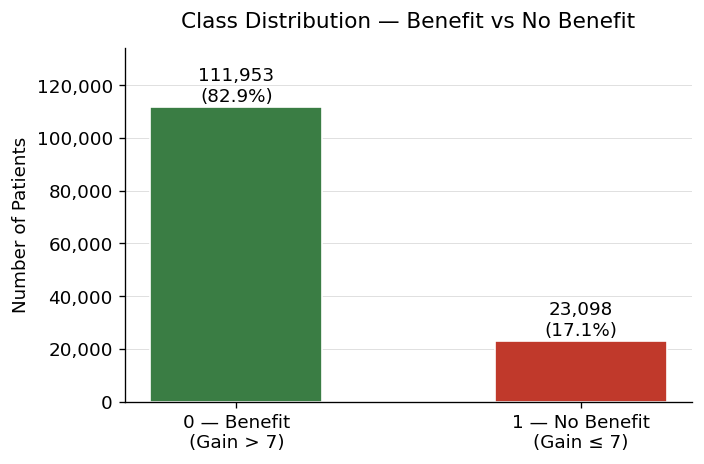


Imbalance ratio  : 4.85  (Benefit : No-Benefit)
⚠  Dataset is imbalanced — the Benefit class is the majority.


In [41]:
labels  = ["0 — Benefit\n(Gain > 7)", "1 — No Benefit\n(Gain ≤ 7)"]
counts  = [n_benefit, n_no_benefit]
colors  = [BENEFIT, NO_BENEFIT]
pcts    = [100 * c / (n_benefit + n_no_benefit) for c in counts]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor="white")

# Annotate each bar with count + percentage
for bar, count, pct in zip(bars, counts, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_title("Class Distribution — Benefit vs No Benefit", fontsize=13, pad=12)
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, max(counts) * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

ratio = n_benefit / n_no_benefit
print(f"\nImbalance ratio  : {ratio:.2f}  (Benefit : No-Benefit)")
if ratio > 1.5:
    print("⚠  Dataset is imbalanced — the Benefit class is the majority.")

### Section 2b — Storytelling View: How the Patient Population Splits

The bar chart above is fine for analysts, but for a stakeholder audience we apply **data-storytelling principles**:

| Principle | How it's applied here |
|-----------|----------------------|
| **Lead with the insight** | The title states the takeaway ("1 in 6 gains no benefit"), not the chart type |
| **One accent colour** | The Benefit majority is grey (context); only the No-Benefit group — the protagonist of our business goal — is red |
| **Declutter** | No axes, gridlines, ticks or legend — a 100% stacked bar with labels placed directly on the data |
| **Connect to the decision** | The subtitle ties the chart to the business goal: find this group pre-surgery with ≥ 80% precision |
| **Show the evidence** | Counts and the data source are included as a footnote for credibility |

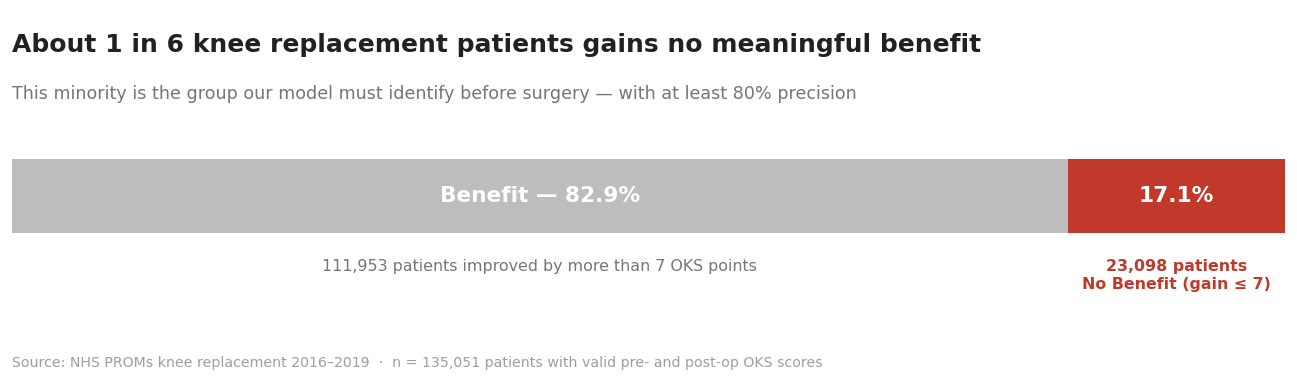

In [42]:
# ── Storytelling view: one bar, one message ──────────────────────────────────
GREY = "#BDBDBD"   # context colour — the majority group is background, not the story

n_valid        = n_benefit + n_no_benefit
pct_benefit    = 100 * n_benefit / n_valid
pct_no_benefit = 100 * n_no_benefit / n_valid
one_in_n       = round(100 / pct_no_benefit)

fig, ax = plt.subplots(figsize=(11, 3.4))

bar_h = 0.42
ax.barh(0, pct_benefit, height=bar_h, color=GREY, zorder=2)
ax.barh(0, pct_no_benefit, left=pct_benefit, height=bar_h, color=NO_BENEFIT, zorder=3)

# Percentages on the data — no legend needed
ax.text(pct_benefit / 2, 0, f"Benefit — {pct_benefit:.1f}%",
        ha="center", va="center", fontsize=13, color="white", fontweight="bold")
ax.text(pct_benefit + pct_no_benefit / 2, 0, f"{pct_no_benefit:.1f}%",
        ha="center", va="center", fontsize=13, color="white", fontweight="bold")

# Counts + meaning directly under each segment
ax.text(pct_benefit / 2, -0.36,
        f"{n_benefit:,} patients improved by more than {THRESHOLD} OKS points",
        ha="center", va="top", fontsize=9.5, color="#757575")
ax.text(pct_benefit + pct_no_benefit / 2, -0.36,
        f"{n_no_benefit:,} patients\nNo Benefit (gain ≤ {THRESHOLD})",
        ha="center", va="top", fontsize=9.5, color=NO_BENEFIT, fontweight="bold")

# Headline = the takeaway, subtitle = the context
ax.text(0, 0.86, f"About 1 in {one_in_n} knee replacement patients gains no meaningful benefit",
        ha="left", va="center", fontsize=15, fontweight="bold", color="#212121")
ax.text(0, 0.58, "This minority is the group our model must identify before surgery — "
                 "with at least 80% precision",
        ha="left", va="center", fontsize=10.5, color="#757575")

# Source / sample-size footnote
ax.text(0, -0.95, f"Source: NHS PROMs knee replacement 2016–2019  ·  "
                  f"n = {n_valid:,} patients with valid pre- and post-op OKS scores",
        ha="left", va="center", fontsize=8.5, color="#9E9E9E")

ax.set_xlim(0, 100)
ax.set_ylim(-1.05, 1.05)
ax.axis("off")
plt.tight_layout()
plt.show()

### Section 2c — Storytelling View: No-Benefit Rate by Age Band

The overall 17% no-benefit rate is not spread evenly across ages. This view answers the follow-up question a stakeholder will naturally ask: **"who are these no-benefit patients?"**

**Colour grammar** (consistent across all storytelling views, so a business reader learns it once):

| Colour | Meaning |
|--------|---------|
| 🟥 Red | The no-benefit patient group itself (view 2b only) |
| ⬛ Dark grey | Emphasis — this subgroup sits **above** the overall no-benefit average |
| ⬜ Grey | Context — at or below average; pale grey = too few patients to judge |

Storytelling choices:

| Principle | How it's applied here |
|-----------|----------------------|
| **Lead with the insight** | The headline states the pattern (younger = higher risk), not "bar chart of rates" |
| **Emphasis by darkness, not hue** | Only age bands **above** the overall average are dark; the rest stay light — red is reserved for the no-benefit group itself, since even the worst age band here is still ~80% benefiters |
| **Honest about uncertainty** | Bands with fewer than 1,000 patients (e.g. 90+) are shown pale — a low rate from 23 patients is noise, not signal |
| **Reference line** | The dashed overall average gives the eye an anchor to compare every bar against |
| **Evidence on the chart** | Sample size (n) sits under each age band, so the reader can judge reliability without a separate table |

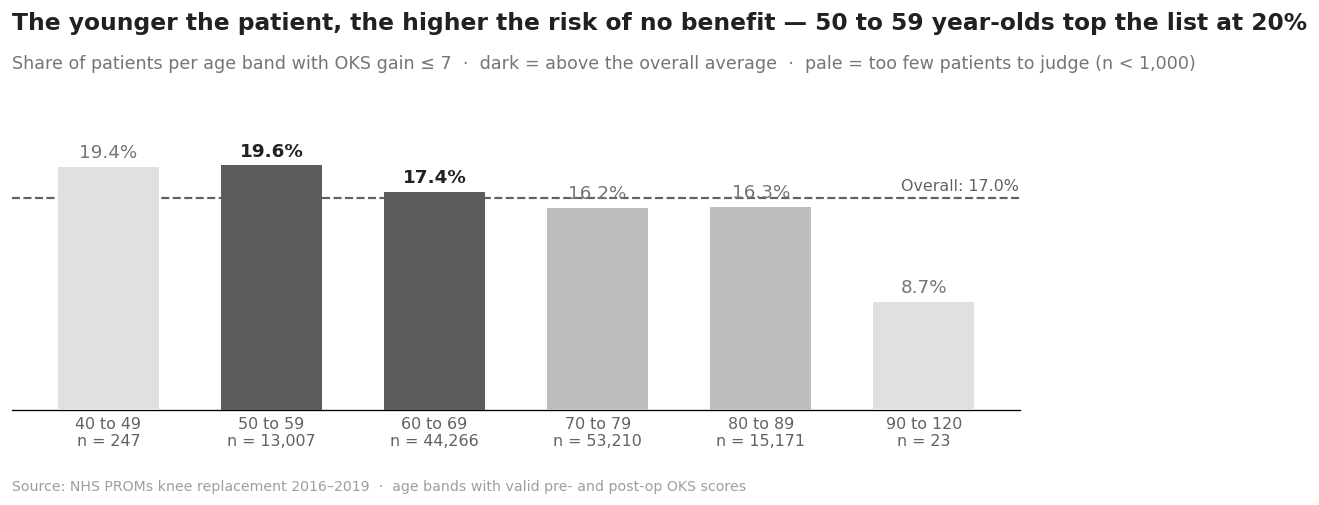

In [43]:
# ── Storytelling view 2: where does "No Benefit" concentrate? ────────────────
# Colour grammar across all storytelling views:
#   red       = the no-benefit patient group itself (view 2b only)
#   dark grey = emphasis — this subgroup sits above the overall average
#   grey      = context — at or below average;  pale grey = too few patients to judge
GREY        = "#BDBDBD"
PALE        = "#E0E0E0"
ACCENT      = "#5C5C5C"
ACCENT_TEXT = "#212121"   # near-black — keeps emphasised labels readable
MIN_N       = 1_000       # reliability cut-off for highlighting a band

AGE_COL_SB   = "Age Band"
AGE_ORDER_SB = ["40 to 49", "50 to 59", "60 to 69", "70 to 79", "80 to 89", "90 to 120"]

nb_age = (
    df.filter(pl.col("Benefit Label").is_not_null() & pl.col(AGE_COL_SB).is_not_null())
    .group_by(AGE_COL_SB)
    .agg([
        (pl.col("Benefit Label") == 1).sum().alias("n_no_benefit"),
        pl.len().alias("n_total"),
    ])
    .with_columns((100 * pl.col("n_no_benefit") / pl.col("n_total")).alias("No-Benefit %"))
    .to_pandas()
    .set_index(AGE_COL_SB)
    .reindex(AGE_ORDER_SB)
    .dropna()
    .reset_index()
)

overall_nb = 100 * nb_age["n_no_benefit"].sum() / nb_age["n_total"].sum()

# The headline is computed from the data, so it stays true if the data changes
reliable = nb_age[nb_age["n_total"] >= MIN_N]
worst    = reliable.loc[reliable["No-Benefit %"].idxmax()]

fig, ax = plt.subplots(figsize=(11, 4.8))

for _, row in nb_age.iterrows():
    small = row["n_total"] < MIN_N
    above = row["No-Benefit %"] > overall_nb
    color = PALE if small else (ACCENT if above else GREY)
    ax.bar(row[AGE_COL_SB], row["No-Benefit %"], color=color, width=0.62, zorder=3)
    ax.text(row[AGE_COL_SB], row["No-Benefit %"] + 0.45, f"{row['No-Benefit %']:.1f}%",
            ha="center", va="bottom", fontsize=11,
            fontweight="bold" if (above and not small) else "normal",
            color=ACCENT_TEXT if (above and not small) else "#757575")

# Overall average as the reference the eye compares each bar against
ax.axhline(overall_nb, color="#616161", linestyle="--", linewidth=1.3, zorder=2)
ax.text(len(nb_age) - 0.42, overall_nb + 0.35, f"Overall: {overall_nb:.1f}%",
        ha="right", va="bottom", fontsize=9.5, color="#616161")

# Sample size under each band — evidence without clutter
ax.set_xticks(range(len(nb_age)))
ax.set_xticklabels([f"{r[AGE_COL_SB]}\nn = {r['n_total']:,}" for _, r in nb_age.iterrows()],
                   fontsize=9.5, color="#616161")

# Headline = the takeaway, subtitle = how to read the chart
ax.text(0, 1.20, f"The younger the patient, the higher the risk of no benefit — "
                 f"{worst[AGE_COL_SB]} year-olds top the list at {worst['No-Benefit %']:.0f}%",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.08, f"Share of patients per age band with OKS gain ≤ {THRESHOLD}  ·  "
                 f"dark = above the overall average  ·  pale = too few patients to judge (n < {MIN_N:,})",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.22, "Source: NHS PROMs knee replacement 2016–2019  ·  "
                  "age bands with valid pre- and post-op OKS scores",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

# Declutter: bars + labels carry all the information, the y-axis adds nothing
ax.set_ylim(0, nb_age["No-Benefit %"].max() * 1.28)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

### Section 2d — Storytelling View: Pre-Op Severity Gradient

The single strongest no-benefit signal in the dataset: **the healthier the knee before surgery, the less the operation helps.** The no-benefit rate climbs monotonically from ~12% (severe pre-op symptoms) to ~68% (minimal symptoms).

Storytelling choices:

| Principle | How it's applied here |
|-----------|----------------------|
| **Lead with the insight** | The headline states the gradient and its most striking number (2 in 3 minimal-symptom patients gain nothing) |
| **Emphasis by darkness, not hue** | Severity bands above the overall average are dark grey — red stays reserved for the no-benefit group itself |
| **Explain the mechanism** | An annotation flags the hard ceiling: a patient with pre-op OKS above 41 *cannot* gain more than 7 points (max score is 48), so part of this effect is mathematical, not biological |
| **Reference line** | Dashed overall average anchors every comparison |
| **Honest caveat** | Footnote notes this is a univariate view — severity correlates with age and comorbidity |

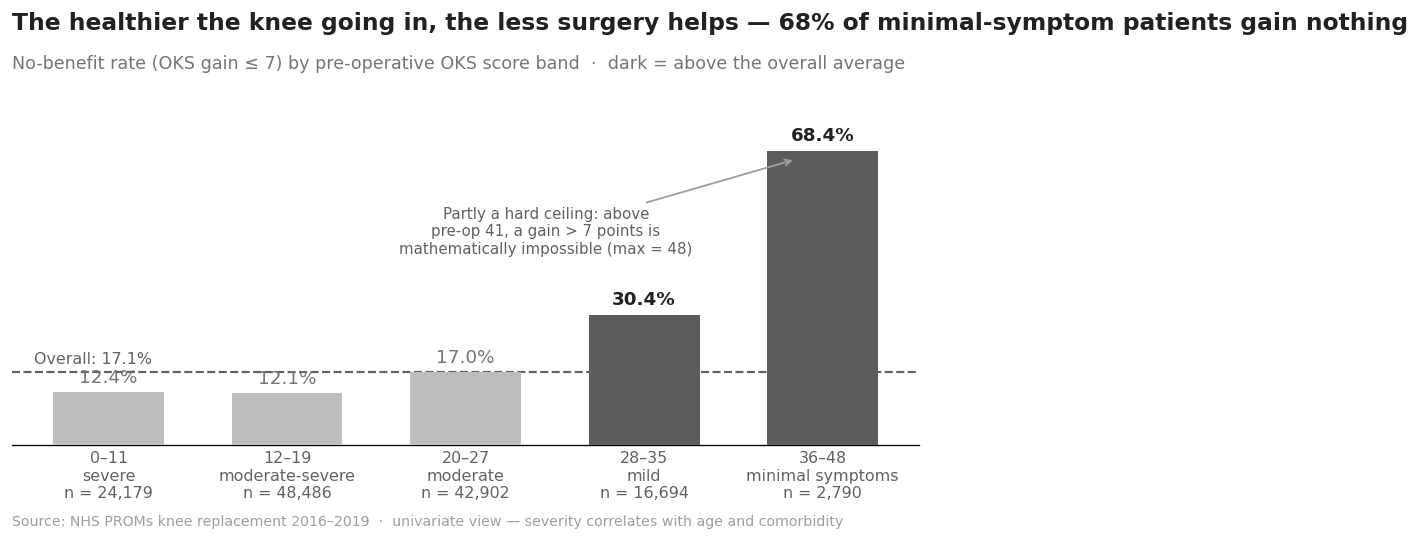

In [44]:
# ── Storytelling view 3: pre-op severity — the strongest signal we have ──────
GREY        = "#BDBDBD"
ACCENT      = "#5C5C5C"   # emphasis — above the overall average (red stays reserved for the no-benefit group itself)
ACCENT_TEXT = "#212121"

PRE_BANDS = [
    (0, 11,  "0–11",  "severe"),
    (12, 19, "12–19", "moderate-severe"),
    (20, 27, "20–27", "moderate"),
    (28, 35, "28–35", "mild"),
    (36, 48, "36–48", "minimal symptoms"),
]

sev = df.filter(pl.col("Benefit Label").is_not_null() & pl.col(PRE_COL).is_not_null())
overall_nb = 100 * (sev["Benefit Label"] == 1).sum() / sev.height

rows = []
for lo, hi, rng, desc in PRE_BANDS:
    sub = sev.filter((pl.col(PRE_COL) >= lo) & (pl.col(PRE_COL) <= hi))
    nb  = int((sub["Benefit Label"] == 1).sum())
    rows.append({"range": rng, "desc": desc, "n": sub.height, "pct": 100 * nb / sub.height})
sev_pd = pd.DataFrame(rows)
worst_pct = sev_pd["pct"].iloc[-1]

fig, ax = plt.subplots(figsize=(11, 5))

for i, row in sev_pd.iterrows():
    above = row["pct"] > overall_nb
    ax.bar(i, row["pct"], color=ACCENT if above else GREY, width=0.62, zorder=3)
    ax.text(i, row["pct"] + 1.2, f"{row['pct']:.1f}%", ha="center", va="bottom", fontsize=11,
            fontweight="bold" if above else "normal",
            color=ACCENT_TEXT if above else "#757575")

ax.axhline(overall_nb, color="#616161", linestyle="--", linewidth=1.3, zorder=2)
ax.text(-0.42, overall_nb + 1.2, f"Overall: {overall_nb:.1f}%",
        ha="left", va="bottom", fontsize=9.5, color="#616161")

ax.set_xticks(range(len(sev_pd)))
ax.set_xticklabels([f"{r['range']}\n{r['desc']}\nn = {r['n']:,}" for _, r in sev_pd.iterrows()],
                   fontsize=9.5, color="#616161")

# The mechanism, not just the pattern: above pre-op 41 a 7-point gain is impossible
ax.annotate("Partly a hard ceiling: above\npre-op 41, a gain > 7 points is\nmathematically impossible (max = 48)",
            xy=(len(sev_pd) - 1.15, worst_pct - 2), xytext=(len(sev_pd) - 2.55, worst_pct - 13),
            fontsize=9, color="#616161", ha="center", va="top",
            arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1.1))

# Headline = the takeaway, subtitle = how to read the chart
ax.text(0, 1.18, f"The healthier the knee going in, the less surgery helps — "
                 f"{worst_pct:.0f}% of minimal-symptom patients gain nothing",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.07, f"No-benefit rate (OKS gain ≤ {THRESHOLD}) by pre-operative OKS score band  ·  "
                 f"dark = above the overall average",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.20, "Source: NHS PROMs knee replacement 2016–2019  ·  univariate view — "
                  "severity correlates with age and comorbidity",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_ylim(0, sev_pd["pct"].max() * 1.18)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

### Section 2e — Storytelling View: Which Patient Factors Raise No-Benefit Risk?

Beyond the knee itself, **whole-body health shapes the outcome**. This view ranks pre-operative risk factors by their no-benefit rate, so a stakeholder can see at a glance which patient profiles deserve a closer pre-surgery conversation.

Storytelling choices:

| Principle | How it's applied here |
|-----------|----------------------|
| **Ranked, not alphabetical** | Factors are sorted by risk so the visual order *is* the message |
| **Distance = excess risk** | Each dot's distance from the dashed overall line shows how much that factor adds |
| **Emphasis by darkness, not hue** | Dark dots mark elevated risk — not the no-benefit outcome itself; red stays reserved for that group, and the light grey connectors are just visual guides |
| **Evidence on the chart** | Each factor carries its n, so rare factors can't masquerade as strong ones |
| **Honest caveat** | Factors overlap (a patient can have several) — this is a univariate view, not additive effects |

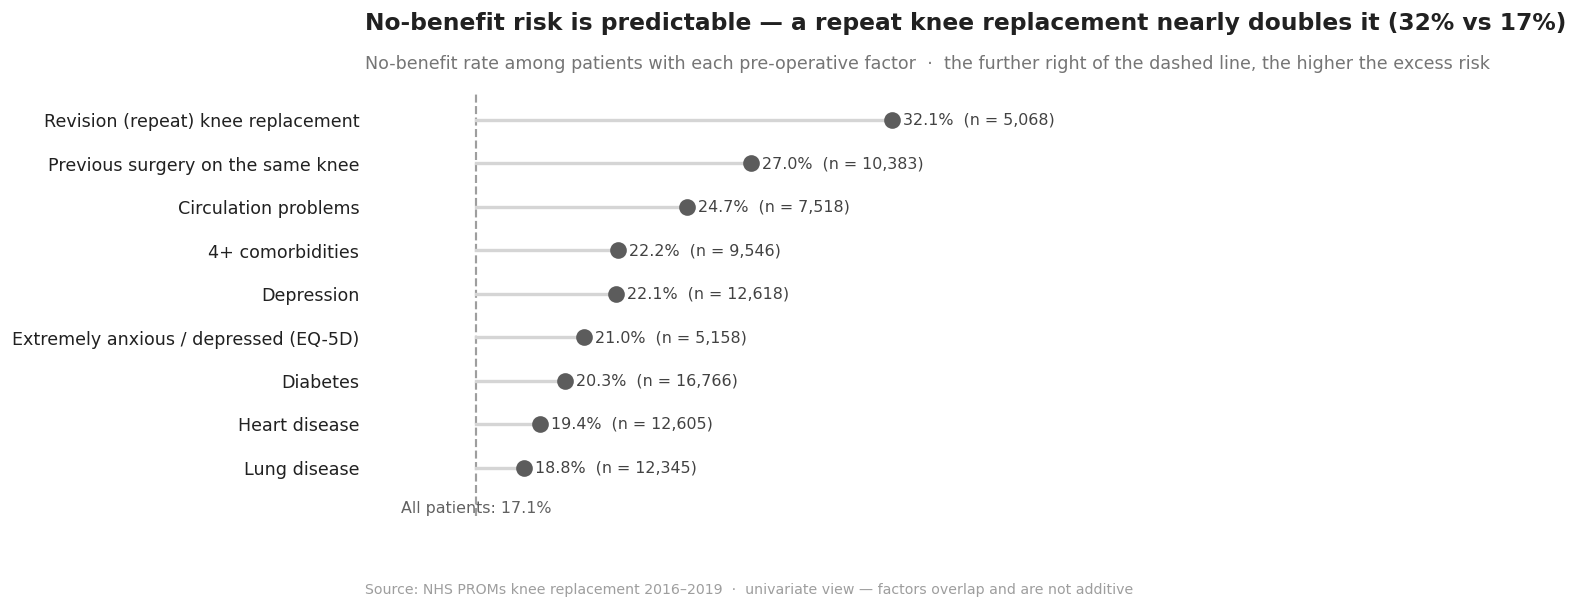

In [45]:
# ── Storytelling view 4: patient risk factors, ranked ────────────────────────
ACCENT = "#5C5C5C"   # emphasis — elevated risk (red stays reserved for the no-benefit group itself)

COMO_COLS = ["Heart Disease", "High Bp", "Stroke", "Circulation", "Lung Disease",
             "Diabetes", "Kidney Disease", "Nervous System", "Liver Disease",
             "Cancer", "Depression", "Arthritis"]   # NHS coding: 1 = yes, 9 = no

base = (
    df.filter(pl.col("Benefit Label").is_not_null())
    .with_columns(
        pl.sum_horizontal([(pl.col(c) == 1).cast(pl.UInt8) for c in COMO_COLS])
          .alias("_n_como")
    )
)
overall_nb = 100 * (base["Benefit Label"] == 1).sum() / base.height

FACTORS = [
    ("Revision (repeat) knee replacement",      pl.col("Revision Flag") == 1),
    ("Previous surgery on the same knee",       pl.col("Pre-Op Q Previous Surgery") == 1),
    ("Circulation problems",                    pl.col("Circulation") == 1),
    ("4+ comorbidities",                        pl.col("_n_como") >= 4),
    ("Depression",                              pl.col("Depression") == 1),
    ("Extremely anxious / depressed (EQ-5D)",   pl.col("Pre-Op Q Anxiety") == 3),
    ("Diabetes",                                pl.col("Diabetes") == 1),
    ("Heart disease",                           pl.col("Heart Disease") == 1),
    ("Lung disease",                            pl.col("Lung Disease") == 1),
]

rows = []
for name, cond in FACTORS:
    sub = base.filter(cond)
    nb  = int((sub["Benefit Label"] == 1).sum())
    rows.append({"factor": name, "n": sub.height, "pct": 100 * nb / sub.height})
rf = pd.DataFrame(rows).sort_values("pct", ascending=True).reset_index(drop=True)
worst = rf.iloc[-1]

fig, ax = plt.subplots(figsize=(11, 5.4))

ax.axvline(overall_nb, color="#9E9E9E", linestyle="--", linewidth=1.3, zorder=2)
ax.text(overall_nb, -0.75, f"All patients: {overall_nb:.1f}%",
        ha="center", va="top", fontsize=9.5, color="#616161")

for i, row in rf.iterrows():
    ax.plot([overall_nb, row["pct"]], [i, i], color="#D5D5D5", linewidth=2, zorder=2)
    ax.plot(row["pct"], i, "o", color=ACCENT, markersize=9, zorder=3)
    ax.text(row["pct"] + 0.4, i, f"{row['pct']:.1f}%  (n = {row['n']:,})",
            ha="left", va="center", fontsize=9.5, color="#424242")

ax.set_yticks(range(len(rf)))
ax.set_yticklabels(rf["factor"], fontsize=10.5, color="#212121")

# Headline = the takeaway, subtitle = how to read the chart
ax.text(0, 1.14, f"No-benefit risk is predictable — a repeat knee replacement "
                 f"nearly doubles it ({worst['pct']:.0f}% vs {overall_nb:.0f}%)",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.05, "No-benefit rate among patients with each pre-operative factor  ·  "
                 "the further right of the dashed line, the higher the excess risk",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.16, "Source: NHS PROMs knee replacement 2016–2019  ·  univariate view — "
                  "factors overlap and are not additive",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_xlim(overall_nb - 4, rf["pct"].max() + 8)
ax.set_ylim(-1.1, len(rf) - 0.4)
ax.set_xticks([])
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

### Section 2f — Storytelling View: The Iterative Modelling Journey

How we got to our conclusions matters as much as the conclusions themselves. The project did not run one model — it cycled through **data preparation (2.0–2.7) → modelling (3.1–3.7) → evaluation (4.0–4.3)** seven times, each pass driven by an unsatisfying result or a new idea, until the evidence said no further improvement was possible.

Two figures tell this story:

1. **Figure 1 — the process**: the prep → model → evaluate cycle and the seven passes through it
2. **Figure 2 — the proof**: test RMSE per pass, flat-lining at the ~8.0 information ceiling — *why* the loop stopped

Storytelling choices:

| Principle | How it's applied here |
|-----------|----------------------|
| **Process, then proof** | The cycle diagram shows *how* we worked; the convergence chart shows *why* we stopped — neither alone tells the full story |
| **Lead with the insight** | Headlines state the takeaways ("we ran the whole cycle seven times", "seven strategies, one ceiling") |
| **Emphasis by darkness, not hue** | Greyscale throughout; the best result and the feedback loop are dark — red stays reserved for the no-benefit group (view 2b) |
| **Honest about failure** | Iterations that made things *worse* (3.5–3.7) are shown, not hidden — the flat line is the finding |
| **Evidence on the chart** | Every point carries its RMSE; the source is cited |

> **Note:** the metrics in Figure 2 are transcribed from `deliverables/WorkInProgress/Modelling-Conclusions.md` (they are produced by the 3.x modelling notebooks, not computed here). If a 3.x notebook is re-run with different results, update the values in the cell below.

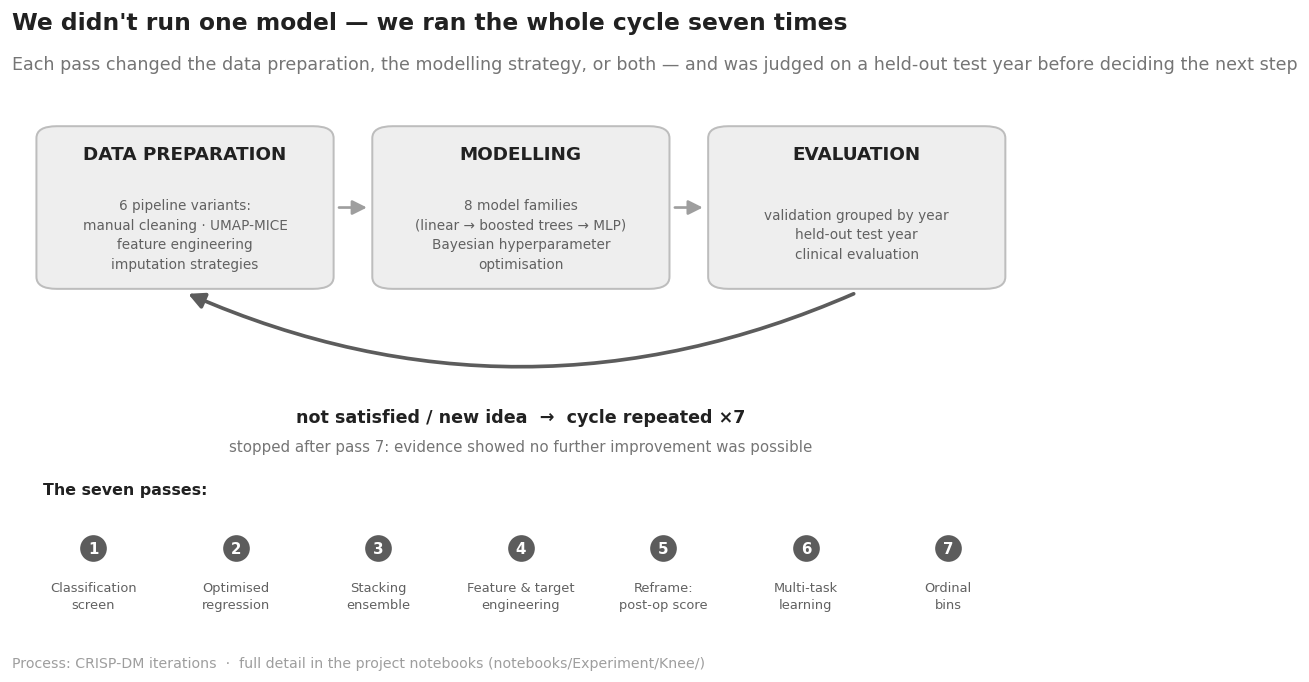

In [58]:
# ── Figure 1: the iterative process — prep → model → evaluate, repeated ×7 ───
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

GREY        = "#BDBDBD"
PALE        = "#EEEEEE"
ACCENT      = "#5C5C5C"   # emphasis — the feedback loop is the story
ACCENT_TEXT = "#212121"

STAGES = [
    ("DATA PREPARATION", "6 pipeline variants:\nmanual cleaning · UMAP-MICE\nfeature engineering\nimputation strategies"),
    ("MODELLING",        "8 model families\n(linear → boosted trees → MLP)\nBayesian hyperparameter\noptimisation"),
    ("EVALUATION",       "validation grouped by year\nheld-out test year\nclinical evaluation"),
]

PASSES = [
    ("1", "Classification\nscreen"),
    ("2", "Optimised\nregression"),
    ("3", "Stacking\nensemble"),
    ("4", "Feature & target\nengineering"),
    ("5", "Reframe:\npost-op score"),
    ("6", "Multi-task\nlearning"),
    ("7", "Ordinal\nbins"),
]

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis("off")

# Stage boxes
box_y, box_h = 60, 26
box_xs = [(3, 28), (36, 28), (69, 28)]
for (x, w), (title, detail) in zip(box_xs, STAGES):
    ax.add_patch(FancyBboxPatch((x, box_y), w, box_h,
                                boxstyle="round,pad=0.6,rounding_size=2",
                                facecolor=PALE, edgecolor=GREY, linewidth=1.2))
    ax.text(x + w / 2, box_y + box_h - 4, title, ha="center", va="center",
            fontsize=11, fontweight="bold", color=ACCENT_TEXT)
    ax.text(x + w / 2, box_y + box_h / 2 - 4.5, detail, ha="center", va="center",
            fontsize=8.2, color="#616161", linespacing=1.5)

# Forward arrows between stages
for x_from, x_to in [(31.8, 35.2), (64.8, 68.2)]:
    ax.add_patch(FancyArrowPatch((x_from, box_y + box_h / 2), (x_to, box_y + box_h / 2),
                                 arrowstyle="-|>", mutation_scale=18,
                                 color="#9E9E9E", linewidth=1.6))

# Feedback loop — bows downward below the boxes (negative rad), dark = emphasis
ax.add_patch(FancyArrowPatch((83, box_y - 1.2), (17, box_y - 1.2),
                             connectionstyle="arc3,rad=-0.22",
                             arrowstyle="-|>", mutation_scale=20,
                             color=ACCENT, linewidth=2.2))
ax.text(50, 38, "not satisfied / new idea  →  cycle repeated ×7",
        ha="center", va="center", fontsize=10.5, fontweight="bold", color=ACCENT_TEXT)
ax.text(50, 33, "stopped after pass 7: evidence showed no further improvement was possible",
        ha="center", va="center", fontsize=9, color="#757575")

# The seven passes, in order
ax.text(3, 25, "The seven passes:", fontsize=9.5, fontweight="bold", color=ACCENT_TEXT)
strip_y = 16
for i, (num, label) in enumerate(PASSES):
    cx = 8 + i * 14
    ax.plot(cx, strip_y, "o", markersize=15, color=ACCENT, zorder=3)
    ax.text(cx, strip_y, num, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white", zorder=4)
    ax.text(cx, strip_y - 5.5, label, ha="center", va="top",
            fontsize=7.8, color="#616161", linespacing=1.4)

# Headline = the takeaway, subtitle = the context
ax.text(0, 1.02, "We didn't run one model — we ran the whole cycle seven times",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 0.955, "Each pass changed the data preparation, the modelling strategy, or both — "
                  "and was judged on a held-out test year before deciding the next step",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.02, "Process: CRISP-DM iterations  ·  full detail in the project notebooks "
                  "(notebooks/Experiment/Knee/)",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

plt.tight_layout()
plt.show()

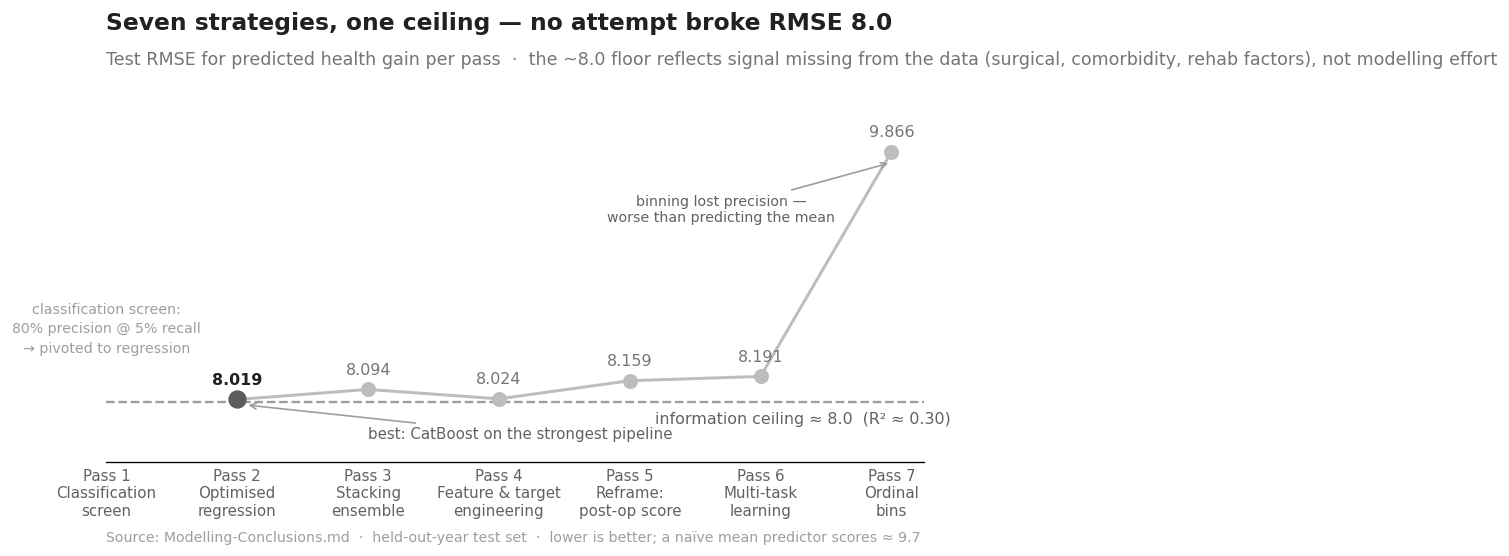

In [59]:
# ── Figure 2: why the loop stopped — seven strategies, one ceiling ───────────
# Metrics transcribed from deliverables/WorkInProgress/Modelling-Conclusions.md
# (test RMSE for health gain, held-out year; passes map to notebooks 3.1–3.7).
# Update here if the modelling notebooks change.
GREY        = "#BDBDBD"
ACCENT      = "#5C5C5C"
ACCENT_TEXT = "#212121"
CEILING     = 8.0

ITERATIONS = [
    # (technique, test RMSE or None)
    ("Classification\nscreen",        None),    # precision/recall task — no RMSE
    ("Optimised\nregression",         8.019),
    ("Stacking\nensemble",            8.094),
    ("Feature & target\nengineering", 8.024),
    ("Reframe:\npost-op score",       8.159),
    ("Multi-task\nlearning",          8.191),
    ("Ordinal\nbins",                 9.866),
]

xs    = [i for i, (_, r) in enumerate(ITERATIONS) if r is not None]
rmses = [r for _, r in ITERATIONS if r is not None]
best_x, best_rmse = min(zip(xs, rmses), key=lambda t: t[1])

fig, ax = plt.subplots(figsize=(11, 5))

# Information ceiling — the finding
ax.axhline(CEILING, color="#9E9E9E", linestyle="--", linewidth=1.4, zorder=2)
ax.text(len(ITERATIONS) - 0.55, CEILING - 0.07,
        f"information ceiling ≈ {CEILING:.1f}  (R² ≈ 0.30)",
        ha="right", va="top", fontsize=9.5, color="#616161")

# The journey line + points; the best result gets the dark emphasis
ax.plot(xs, rmses, color=GREY, linewidth=1.8, zorder=3)
for x, r in zip(xs, rmses):
    is_best = x == best_x
    ax.plot(x, r, "o", markersize=10 if is_best else 8,
            color=ACCENT if is_best else GREY, zorder=4)
    ax.text(x, r + 0.09, f"{r:.3f}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold" if is_best else "normal",
            color=ACCENT_TEXT if is_best else "#757575")

ax.annotate("best: CatBoost on the strongest pipeline", xy=(best_x + 0.06, best_rmse - 0.04),
            xytext=(best_x + 1.0, CEILING - 0.24), fontsize=9, color="#616161",
            ha="left", va="center",
            arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1.0))
ax.annotate("binning lost precision —\nworse than predicting the mean",
            xy=(6, 9.866 - 0.08), xytext=(4.7, 9.55), fontsize=8.5,
            ha="center", va="top", color="#616161",
            arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1.0))

# Pass 1 has no RMSE — it was the classification screen that motivated the pivot
ax.text(0, 8.55, "classification screen:\n80% precision @ 5% recall\n→ pivoted to regression",
        ha="center", va="center", fontsize=8.5, color="#9E9E9E", linespacing=1.5)

ax.set_xticks(range(len(ITERATIONS)))
ax.set_xticklabels([f"Pass {i + 1}\n{tech}" for i, (tech, _) in enumerate(ITERATIONS)],
                   fontsize=9, color="#616161")

# Headline = the takeaway, subtitle = the meaning
ax.text(0, 1.14, "Seven strategies, one ceiling — no attempt broke RMSE 8.0",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.05, "Test RMSE for predicted health gain per pass  ·  the ~8.0 floor reflects signal "
                 "missing from the data (surgical, comorbidity, rehab factors), not modelling effort",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.18, "Source: Modelling-Conclusions.md  ·  held-out-year test set  ·  "
                  "lower is better; a naïve mean predictor scores ≈ 9.7",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_ylim(7.55, 10.35)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

---
## Section 3 — OKS Pre & Post Score Distributions

Comparing the score distributions **before and after surgery** tells us:
- Whether most patients started with low (bad) scores — confirming they genuinely needed surgery
- Whether scores shifted upward after surgery — confirming the procedure helped

Each histogram is plotted separately so the shapes are easy to compare.

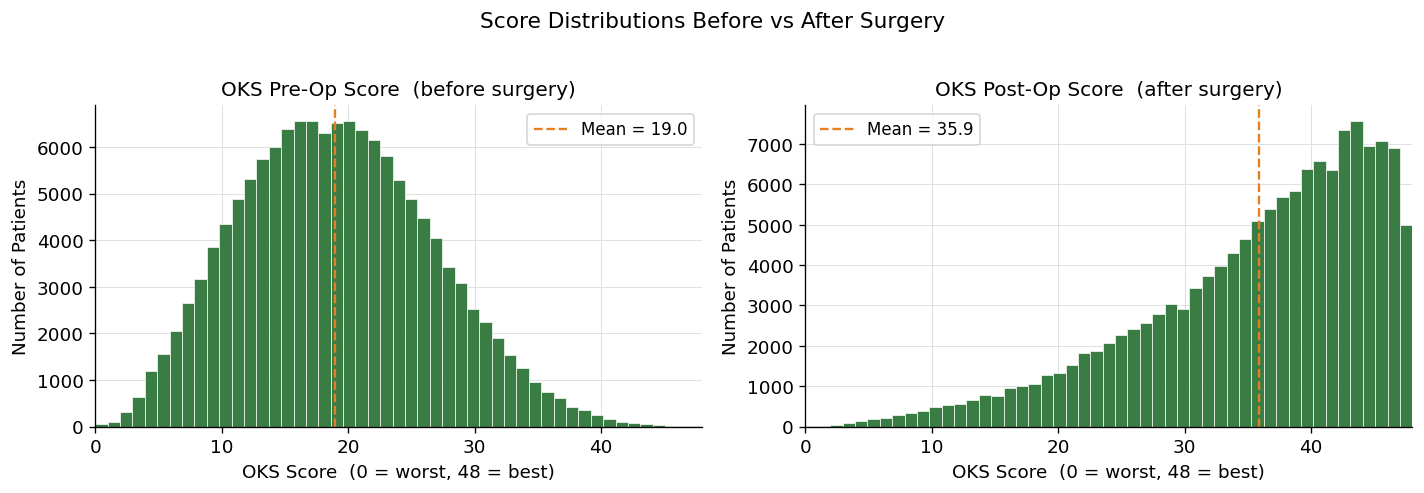

In [46]:
pre_vals  = df[PRE_COL].drop_nulls().to_numpy()
post_vals = df[POST_COL].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, vals, title in zip(
    axes,
    [pre_vals, post_vals],
    ["OKS Pre-Op Score  (before surgery)", "OKS Post-Op Score  (after surgery)"]
):
    ax.hist(vals, bins=49, range=(0, 48), color=BENEFIT, edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("OKS Score  (0 = worst, 48 = best)")
    ax.set_ylabel("Number of Patients")
    ax.set_xlim(0, 48)

    mean_val = vals.mean()
    ax.axvline(mean_val, color=THRESH, linestyle="--", linewidth=1.4, label=f"Mean = {mean_val:.1f}")
    ax.legend(fontsize=10)

fig.suptitle("Score Distributions Before vs After Surgery", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4 — Health Gain Distribution

This histogram shows how much each patient improved.  
The **red dashed line** at x = 7 is the classification threshold.

- Everything to the **right** of the line → **Benefit** (label 0)
- Everything to the **left** of the line → **No Benefit** (label 1)

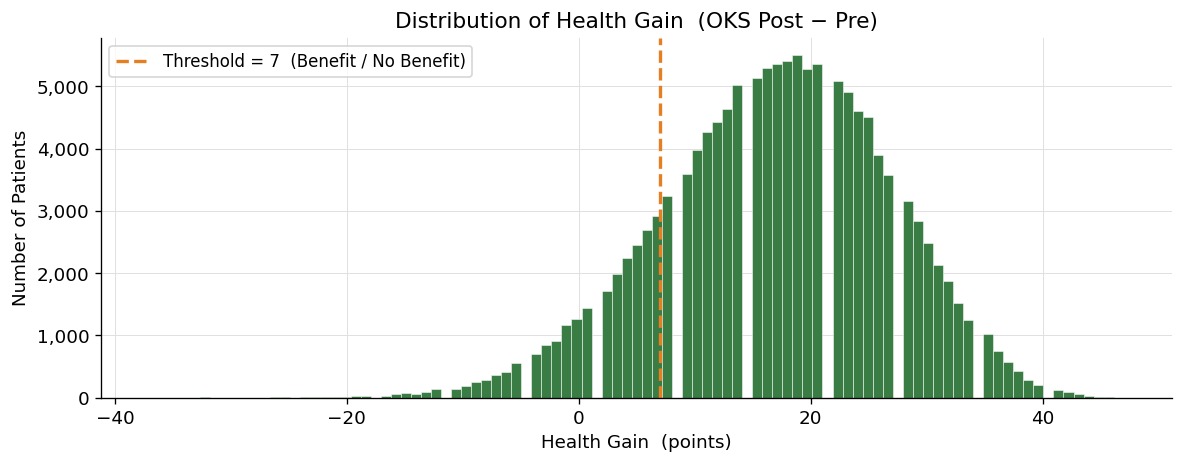

Median health gain : 17.0 points
Mean health gain   : 16.9 points
% patients with gain > 7 : 82.9%


In [47]:
gain_vals = df["Health Gain"].drop_nulls().to_numpy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(gain_vals, bins=97, color=BENEFIT, edgecolor="white", linewidth=0.3)

ax.axvline(THRESHOLD, color=THRESH, linestyle="--", linewidth=2,
           label=f"Threshold = {THRESHOLD}  (Benefit / No Benefit)")

ax.set_title("Distribution of Health Gain  (OKS Post − Pre)", fontsize=13)
ax.set_xlabel("Health Gain  (points)")
ax.set_ylabel("Number of Patients")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"Median health gain : {np.median(gain_vals):.1f} points")
print(f"Mean health gain   : {np.mean(gain_vals):.1f} points")
print(f"% patients with gain > 7 : {100*(gain_vals > 7).mean():.1f}%")

---
## Section 5 — Health Gain by Age Band

Does the patient's age group affect how much they improve?

Each bar shows the **average health gain** for that age band.  
The dashed line marks the threshold — bars above it indicate that the average patient in that group benefited.

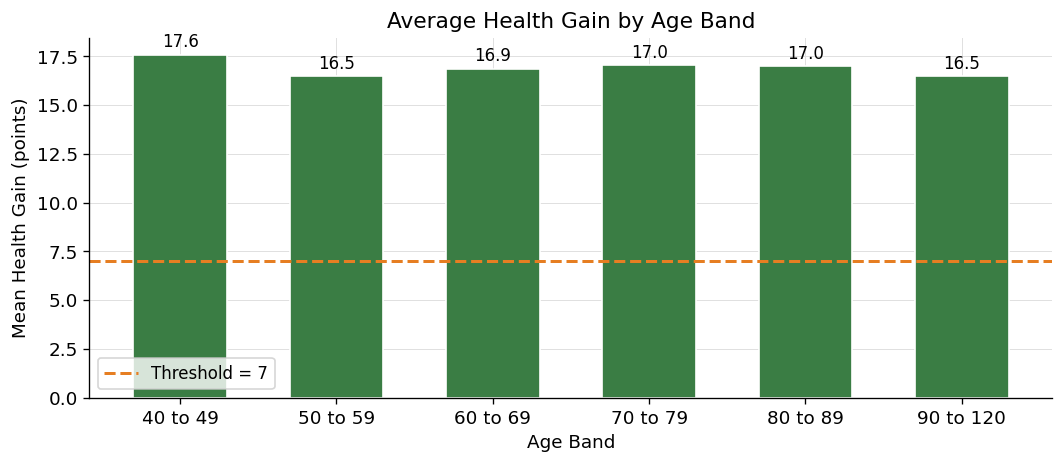

 Age Band  Mean Gain  Median Gain  Count
 40 to 49      17.57        19.00    247
 50 to 59      16.48        17.00  13007
 60 to 69      16.85        17.00  44266
 70 to 79      17.03        17.00  53210
 80 to 89      16.97        17.00  15171
90 to 120      16.48        19.00     23


In [48]:
AGE_COL = "Age Band"

# Ordered age bands present in the data
AGE_ORDER = ["40 to 49", "50 to 59", "60 to 69", "70 to 79", "80 to 89", "90 to 120"]

age_gain = (
    df.filter(pl.col("Health Gain").is_not_null() & pl.col(AGE_COL).is_not_null())
    .group_by(AGE_COL)
    .agg([
        pl.col("Health Gain").mean().alias("Mean Gain"),
        pl.col("Health Gain").median().alias("Median Gain"),
        pl.len().alias("Count"),
    ])
    .to_pandas()
    .set_index(AGE_COL)
    .reindex(AGE_ORDER)
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(age_gain[AGE_COL], age_gain["Mean Gain"], color=BENEFIT, edgecolor="white", width=0.6)

ax.axhline(THRESHOLD, color=THRESH, linestyle="--", linewidth=1.8,
           label=f"Threshold = {THRESHOLD}")

# Annotate bars
for _, row in age_gain.iterrows():
    ax.text(row[AGE_COL], row["Mean Gain"] + 0.2,
            f"{row['Mean Gain']:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average Health Gain by Age Band", fontsize=13)
ax.set_xlabel("Age Band")
ax.set_ylabel("Mean Health Gain (points)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(age_gain[[AGE_COL, "Mean Gain", "Median Gain", "Count"]].to_string(index=False))

---
## Section 6 — Health Gain by Gender

Gender is coded as **1 = Male, 2 = Female** in this dataset.  
The box plot shows the full spread of health gains — median line, interquartile range, and whiskers.

This lets you see whether one gender tends to benefit more than the other.

C:\Users\mittall\AppData\Local\Temp\ipykernel_12532\1095370597.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


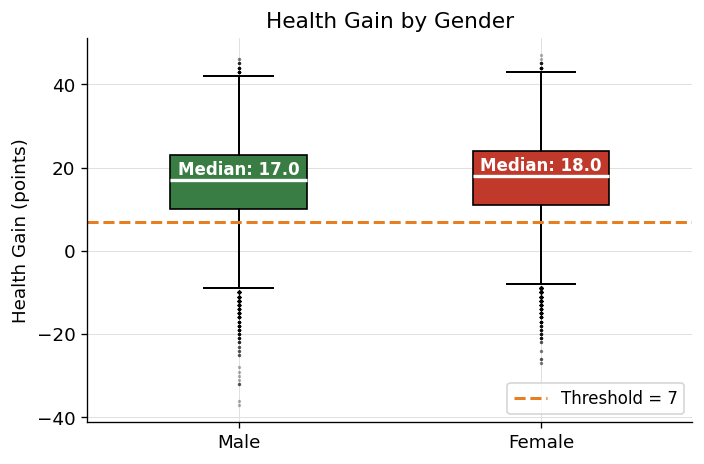

Male      n=54,137  mean=16.4  median=17.0  % benefit=81.9%
Female    n=71,787  mean=17.3  median=18.0  % benefit=83.8%


In [49]:
GENDER_COL = "Gender"

# Map numeric codes to readable labels
df_gender = (
    df.filter(pl.col("Health Gain").is_not_null() & pl.col(GENDER_COL).is_not_null())
    .with_columns(
        pl.col(GENDER_COL).cast(pl.Utf8)
          .map_elements(lambda v: "Male" if v == "1" else ("Female" if v == "2" else "Other"),
                        return_dtype=pl.Utf8)
          .alias("Gender Label")
    )
)

groups = ["Male", "Female"]
data_by_gender = [
    df_gender.filter(pl.col("Gender Label") == g)["Health Gain"].to_numpy()
    for g in groups
]

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data_by_gender,
    labels=groups,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3, color=NO_BENEFIT),
)

for patch, color in zip(bp["boxes"], [BENEFIT, NO_BENEFIT]):
    patch.set_facecolor(color)

ax.axhline(THRESHOLD, color=THRESH, linestyle="--", linewidth=1.8,
           label=f"Threshold = {THRESHOLD}")

# Annotate medians
for i, d in enumerate(data_by_gender, start=1):
    med = np.median(d)
    ax.text(i, med + 0.3, f"Median: {med:.1f}", ha="center", va="bottom", fontsize=10, color="white",
            fontweight="bold")

ax.set_title("Health Gain by Gender", fontsize=13)
ax.set_ylabel("Health Gain (points)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Summary table
for g, d in zip(groups, data_by_gender):
    pct_benefit = 100 * (d > THRESHOLD).mean()
    print(f"{g:8s}  n={len(d):>6,}  mean={d.mean():.1f}  median={np.median(d):.1f}  % benefit={pct_benefit:.1f}%")

---
## Section 7 — Pre-Op Score vs Health Gain

Patients who start with a **very low pre-op score** (worst condition) have more room to improve.  
Patients who start with a **high pre-op score** may already be near their ceiling.

This scatter plot reveals whether the starting condition predicts the health gain,  
which is a known phenomenon called **regression to the mean**.

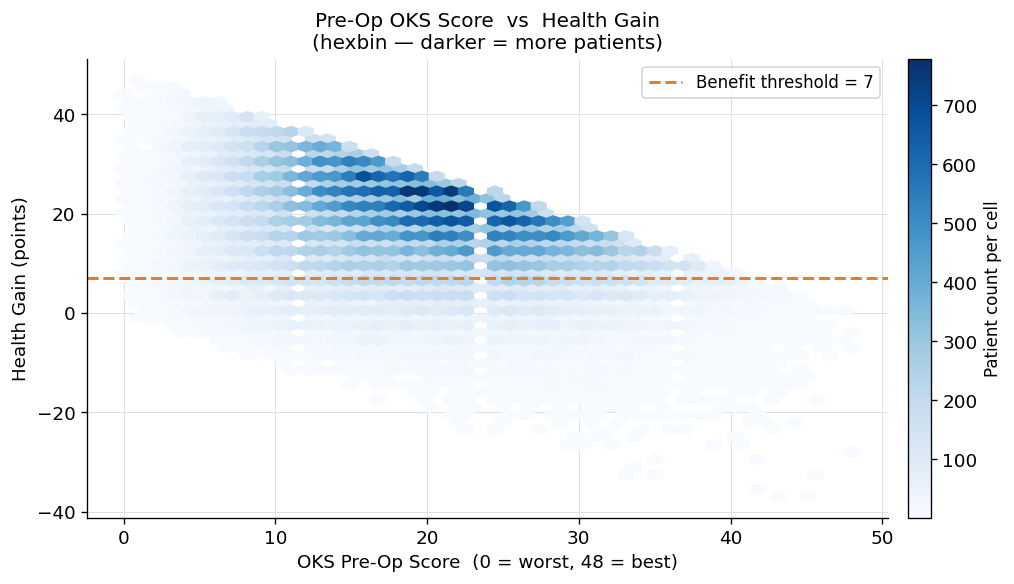

Pearson correlation (Pre-Op Score vs Health Gain): -0.442


In [50]:
df_scatter = (
    df.filter(pl.col("Health Gain").is_not_null())
    .select([PRE_COL, "Health Gain"])
    .to_pandas()
)

# Use a 2D hexbin to avoid overplotting (dataset is large)
fig, ax = plt.subplots(figsize=(9, 5))

hb = ax.hexbin(
    df_scatter[PRE_COL],
    df_scatter["Health Gain"],
    gridsize=50,
    cmap="Blues",
    mincnt=1,
)

ax.axhline(THRESHOLD, color=THRESH, linestyle="--", linewidth=1.8,
           label=f"Benefit threshold = {THRESHOLD}")

cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Patient count per cell", fontsize=10)

ax.set_title("Pre-Op OKS Score  vs  Health Gain\n(hexbin — darker = more patients)", fontsize=12)
ax.set_xlabel(f"OKS Pre-Op Score  (0 = worst, 48 = best)")
ax.set_ylabel("Health Gain (points)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Correlation
corr = df_scatter[PRE_COL].corr(df_scatter["Health Gain"])
print(f"Pearson correlation (Pre-Op Score vs Health Gain): {corr:.3f}")

---
## Section 8 — Benefit Rate by Age Band

Rather than looking at average health gain, this chart shows **what percentage of patients in each age group benefited** (label = 0).

This is a direct answer to the question: *"Does age influence whether surgery is worth it?"*

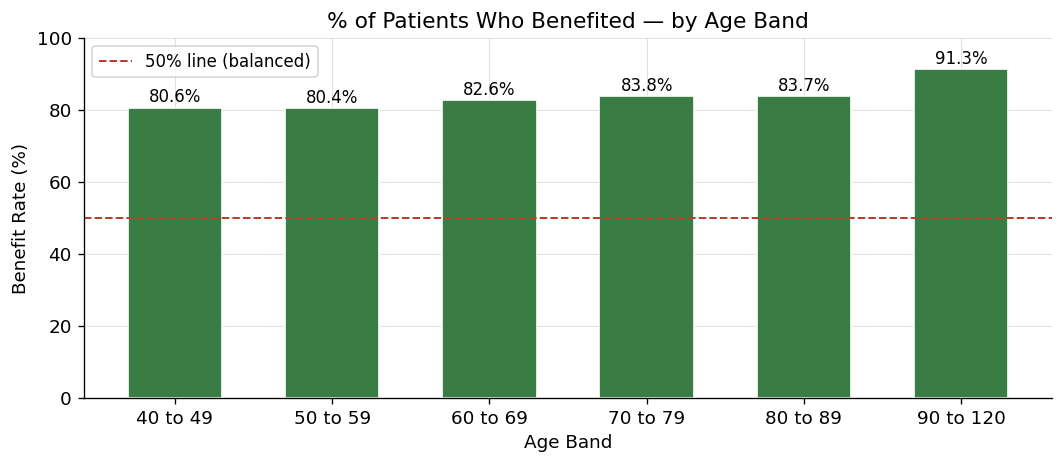

In [51]:
benefit_by_age = (
    df.filter(pl.col("Benefit Label").is_not_null() & pl.col(AGE_COL).is_not_null())
    .group_by(AGE_COL)
    .agg([
        (pl.col("Benefit Label") == 0).sum().alias("n_benefit"),
        pl.len().alias("n_total"),
    ])
    .with_columns(
        (100 * pl.col("n_benefit") / pl.col("n_total")).alias("Benefit Rate %")
    )
    .to_pandas()
    .set_index(AGE_COL)
    .reindex(AGE_ORDER)
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(benefit_by_age[AGE_COL], benefit_by_age["Benefit Rate %"],
       color=BENEFIT, edgecolor="white", width=0.6)

ax.axhline(50, color=NO_BENEFIT, linestyle="--", linewidth=1.2, label="50% line (balanced)")

for _, row in benefit_by_age.iterrows():
    ax.text(row[AGE_COL], row["Benefit Rate %"] + 0.5,
            f"{row['Benefit Rate %']:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("% of Patients Who Benefited — by Age Band", fontsize=13)
ax.set_xlabel("Age Band")
ax.set_ylabel("Benefit Rate (%)")
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 9 — Year-Over-Year Benefit Rate

Does the proportion of patients benefiting change across the three data collection years?  
A consistent rate confirms the label is stable; a trend might indicate changes in patient selection or reporting.

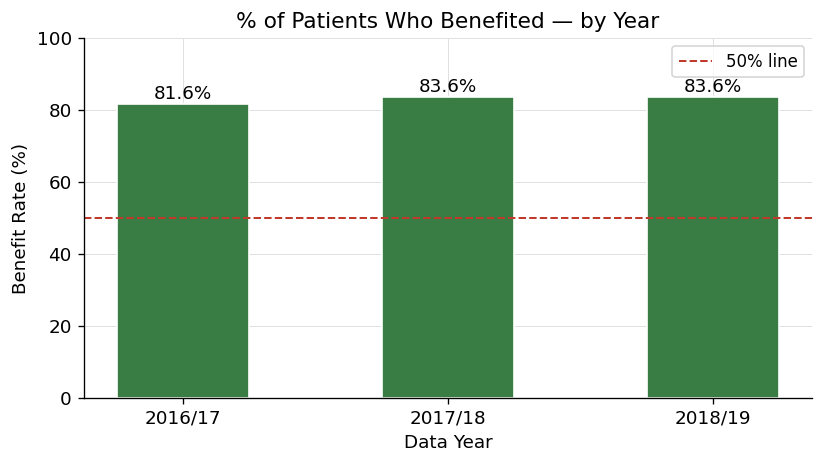

   Year  n_benefit  n_no_benefit  n_total  Benefit Rate %
2016/17      37909          8529    46438           81.63
2017/18      37041          7290    44331           83.56
2018/19      37003          7279    44282           83.56


In [52]:
YEAR_COL = "Year"
year_order = ["2016/17", "2017/18", "2018/19"]

benefit_by_year = (
    df.filter(pl.col("Benefit Label").is_not_null() & pl.col(YEAR_COL).is_not_null())
    .group_by(YEAR_COL)
    .agg([
        (pl.col("Benefit Label") == 0).sum().alias("n_benefit"),
        (pl.col("Benefit Label") == 1).sum().alias("n_no_benefit"),
        pl.len().alias("n_total"),
    ])
    .with_columns(
        (100 * pl.col("n_benefit") / pl.col("n_total")).alias("Benefit Rate %")
    )
    .to_pandas()
    .set_index(YEAR_COL)
    .reindex(year_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(benefit_by_year[YEAR_COL], benefit_by_year["Benefit Rate %"],
       color=BENEFIT, edgecolor="white", width=0.5)

ax.axhline(50, color=NO_BENEFIT, linestyle="--", linewidth=1.2, label="50% line")

for _, row in benefit_by_year.iterrows():
    ax.text(row[YEAR_COL], row["Benefit Rate %"] + 0.4,
            f"{row['Benefit Rate %']:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set_title("% of Patients Who Benefited — by Year", fontsize=13)
ax.set_xlabel("Data Year")
ax.set_ylabel("Benefit Rate (%)")
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(benefit_by_year[[YEAR_COL, "n_benefit", "n_no_benefit", "n_total", "Benefit Rate %"]].to_string(index=False))

---
## Section 10 — Correlation Heatmap

How strongly do numerical features correlate with each other and with **Health Gain**?

- Values close to **+1** → strong positive relationship
- Values close to **−1** → strong negative relationship
- Values close to **0** → little to no linear relationship

A single-colour (blue) palette keeps it easy to read.

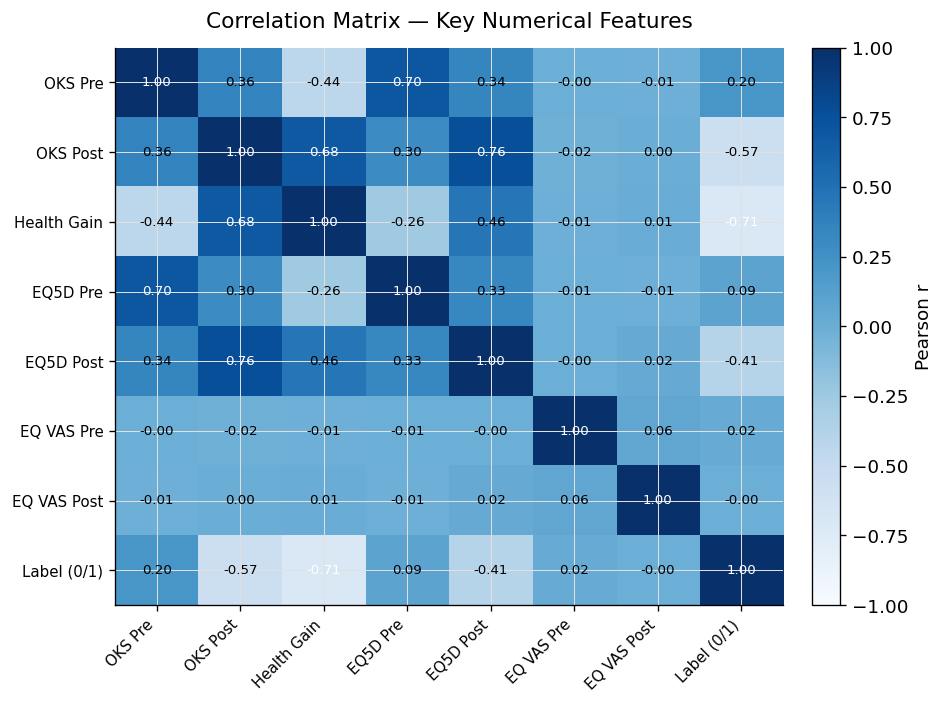

In [53]:
CORR_COLS = [
    "Knee Replacement Pre-Op Q Score",
    "Knee Replacement Post-Op Q Score",
    "Health Gain",
    "Pre-Op Q EQ5D Index",
    "Post-Op Q EQ5D Index",
    "Pre-Op Q EQ VAS",
    "Post-Op Q EQ VAS",
    "Benefit Label",
]

# Keep only columns that exist in the dataframe
CORR_COLS = [c for c in CORR_COLS if c in df.columns]

corr_pd = (
    df.select(CORR_COLS)
    .to_pandas()
    .astype(float)
    .corr()
)

# Short display names
short_names = {
    "Knee Replacement Pre-Op Q Score":  "OKS Pre",
    "Knee Replacement Post-Op Q Score": "OKS Post",
    "Health Gain":                       "Health Gain",
    "Pre-Op Q EQ5D Index":               "EQ5D Pre",
    "Post-Op Q EQ5D Index":              "EQ5D Post",
    "Pre-Op Q EQ VAS":                   "EQ VAS Pre",
    "Post-Op Q EQ VAS":                  "EQ VAS Post",
    "Benefit Label":                     "Label (0/1)",
}
corr_pd = corr_pd.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_pd.values, cmap="Blues", vmin=-1, vmax=1, aspect="auto")

# Tick labels
ax.set_xticks(range(len(corr_pd.columns)))
ax.set_yticks(range(len(corr_pd.index)))
ax.set_xticklabels(corr_pd.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_pd.index, fontsize=9)

# Annotate cells
for i in range(len(corr_pd)):
    for j in range(len(corr_pd.columns)):
        val = corr_pd.values[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=text_color)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Correlation Matrix — Key Numerical Features", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## Section 11 — Missing Data Overview

Before modelling, we need to understand which columns have missing values and how severe the problem is.  
Missing data in the OKS scores directly reduces the labelled set available for training.

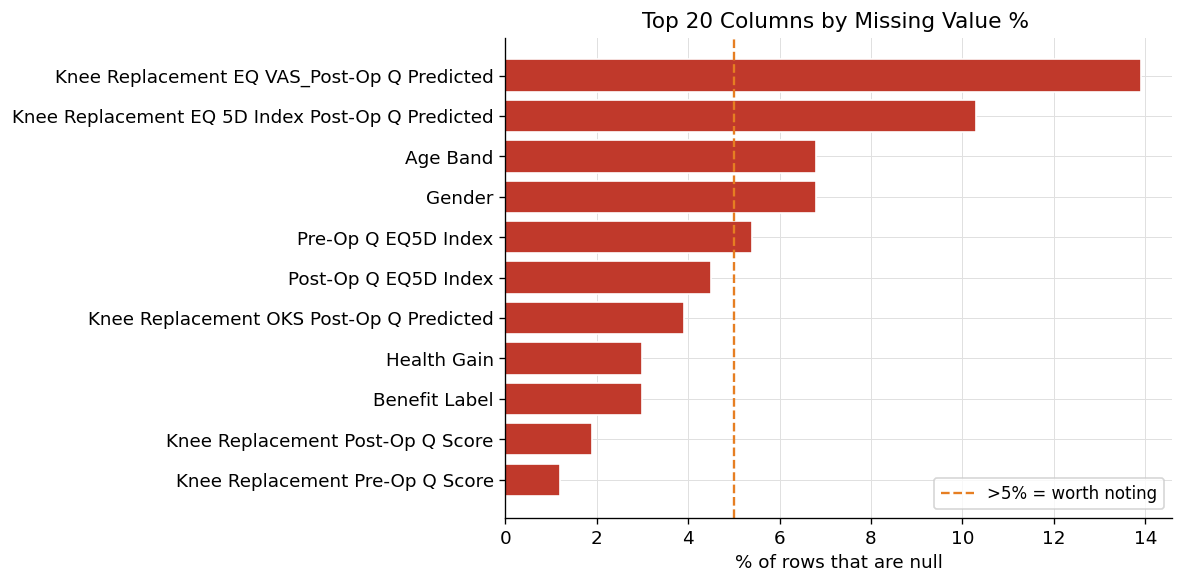


Total rows: 139,236
Columns with any missing: 11

                                          Column  Null Count  Null %
     Knee Replacement EQ VAS_Post-Op Q Predicted       19423   13.90
Knee Replacement EQ 5D Index Post-Op Q Predicted       14322   10.30
                                        Age Band        9402    6.80
                                          Gender        9402    6.80
                             Pre-Op Q EQ5D Index        7500    5.40
                            Post-Op Q EQ5D Index        6274    4.50
        Knee Replacement OKS Post-Op Q Predicted        5381    3.90
                                     Health Gain        4185    3.00
                                   Benefit Label        4185    3.00
                Knee Replacement Post-Op Q Score        2579    1.90
                 Knee Replacement Pre-Op Q Score        1669    1.20


In [54]:
n_total = df.shape[0]

null_counts = (
    df.null_count()
    .transpose(include_header=True, header_name="Column", column_names=["Null Count"])
    .with_columns(
        (100 * pl.col("Null Count") / n_total).round(1).alias("Null %")
    )
    .filter(pl.col("Null Count") > 0)
    .sort("Null %", descending=True)
    .to_pandas()
)

# Show only top 20 columns with most missing values
top_missing = null_counts.head(20)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top_missing["Column"], top_missing["Null %"], color=NO_BENEFIT, edgecolor="white")

ax.set_title("Top 20 Columns by Missing Value % ", fontsize=13)
ax.set_xlabel("% of rows that are null")
ax.set_ylabel("")
ax.invert_yaxis()
ax.axvline(5, color=THRESH, linestyle="--", linewidth=1.4, label=">5% = worth noting")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nTotal rows: {n_total:,}")
print(f"Columns with any missing: {len(null_counts)}")
print()
print(null_counts.head(20).to_string(index=False))

---
## Section 12 — Save Enriched Dataset

Save the dataframe with the **Health Gain** and **Benefit Label** columns added,  
so the next notebook (data preparation) can use this as its starting point.

In [55]:
OUT_PATH = Path("./data/interim/1.3-Health-Gain.parquet")
df.write_parquet(OUT_PATH, compression="gzip")
print(f"Saved  : {OUT_PATH}")
print(f"Shape  : {df.shape}")
print(f"New columns added: 'Health Gain', 'Benefit Label'")

Saved  : data\interim\1.3-Health-Gain.parquet
Shape  : (139236, 84)
New columns added: 'Health Gain', 'Benefit Label'
